In [ ]:
# Dependencies already installed in the 'brats' conda environment
# If needed, run: pip install segmentation-models-pytorch albumentations nibabel pandas matplotlib tqdm ipykernel

In [1]:
import segmentation_models_pytorch as smp
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import albumentations as A
import torch.nn.functional as F
import pandas as pd
import h5py
from tqdm import tqdm

c:\Users\bhmed\anaconda3\envs\brats\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_ZIP_PATH = r'./BraTS.zip'

# Extract dataset

In [3]:
import zipfile

if not os.path.exists('BraTS2020_training_data'):
    with zipfile.ZipFile(DATA_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('.')
    print('Dataset extracted.')
else:
    print('Dataset folder already exists, skipping extraction.')

Dataset folder already exists, skipping extraction.


In [4]:
DATA_DIR = 'BraTS2020_training_data/content/data'
h5_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.h5')])
print(f'Total H5 slices: {len(h5_files)}')
print(f'First 5 files: {h5_files[:5]}')

Total H5 slices: 57195
First 5 files: ['volume_100_slice_0.h5', 'volume_100_slice_1.h5', 'volume_100_slice_10.h5', 'volume_100_slice_100.h5', 'volume_100_slice_101.h5']


In [5]:
# Inspect H5 file structure
with h5py.File(os.path.join(DATA_DIR, h5_files[100]), 'r') as f:
    img = f['image'][:]
    mask = f['mask'][:]
    print(f'Image: shape={img.shape}, dtype={img.dtype}')
    print(f'Mask:  shape={mask.shape}, dtype={mask.dtype}')
    print(f'Image range: [{img.min():.4f}, {img.max():.4f}]')
    print(f'Mask unique values per channel:')
    for ch in range(mask.shape[2]):
        print(f'  Ch{ch}: {np.unique(mask[:,:,ch])}')

Image: shape=(240, 240, 4), dtype=float64
Mask:  shape=(240, 240, 3), dtype=uint8
Image range: [-0.0734, 29.9245]
Mask unique values per channel:
  Ch0: [0]
  Ch1: [0]
  Ch2: [0]


In [6]:
# Read name mapping
data = pd.read_csv(os.path.join(DATA_DIR, 'name_mapping.csv'))
data.head(5)

,Grade,BraTS_2017_subject_ID,BraTS_2018_subject_ID,TCGA_TCIA_subject_ID,BraTS_2019_subject_ID,BraTS_2020_subject_ID
0,HGG,Brats17_CBICA_AAB_1,Brats18_CBICA_AAB_1,NaN,BraTS19_CBICA_AAB_1,BraTS20_Training_001
1,HGG,Brats17_CBICA_AAG_1,Brats18_CBICA_AAG_1,NaN,BraTS19_CBICA_AAG_1,BraTS20_Training_002
2,HGG,Brats17_CBICA_AAL_1,Brats18_CBICA_AAL_1,NaN,BraTS19_CBICA_AAL_1,BraTS20_Training_003
3,HGG,Brats17_CBICA_AAP_1,Brats18_CBICA_AAP_1,NaN,BraTS19_CBICA_AAP_1,BraTS20_Training_004
4,HGG,Brats17_CBICA_ABB_1,Brats18_CBICA_ABB_1,NaN,BraTS19_CBICA_ABB_1,BraTS20_Training_005


In [7]:
# Get unique patient volumes and slice counts
volumes = set()
for f in h5_files:
    # filename format: volume_{id}_slice_{num}.h5
    parts = f.replace('.h5', '').split('_slice_')
    volumes.add(parts[0])
print(f'Unique patient volumes: {len(volumes)}')
print(f'Total slices: {len(h5_files)}')

Unique patient volumes: 369
Total slices: 57195


In [8]:
def cropcentre(arr, cropx, cropy):
    y, x = arr.shape[:2]
    startx = x // 2 - (cropx // 2)
    starty = y // 2 - (cropy // 2)
    if arr.ndim == 3:
        return arr[starty:starty+cropy, startx:startx+cropx, :]
    return arr[starty:starty+cropy, startx:startx+cropx]

In [9]:
# Filter to keep only slices that contain tumor (mask > 0)
tumor_files = []
for f in tqdm(h5_files, desc='Filtering tumor slices'):
    with h5py.File(os.path.join(DATA_DIR, f), 'r') as hf:
        mask = hf['mask'][:]
        if mask.max() > 0:
            tumor_files.append(f)
print(f'Slices with tumor: {len(tumor_files)} / {len(h5_files)}')

Filtering tumor slices: 100%|██████████| 57195/57195 [01:08<00:00, 839.01it/s]

Slices with tumor: 24422 / 57195


In [10]:
# Save filtered file list for the Dataset class
# Use tumor_files so we only train on slices with actual segmentation labels
print(f'Using {len(tumor_files)} slices with tumor content')

Using 24422 slices with tumor content


In [11]:
total_size = sum(os.path.getsize(os.path.join(DATA_DIR, f)) for f in h5_files)
print(f'Dataset size: {total_size / (1024*1024):.1f} MB')

Dataset size: 7579.8 MB


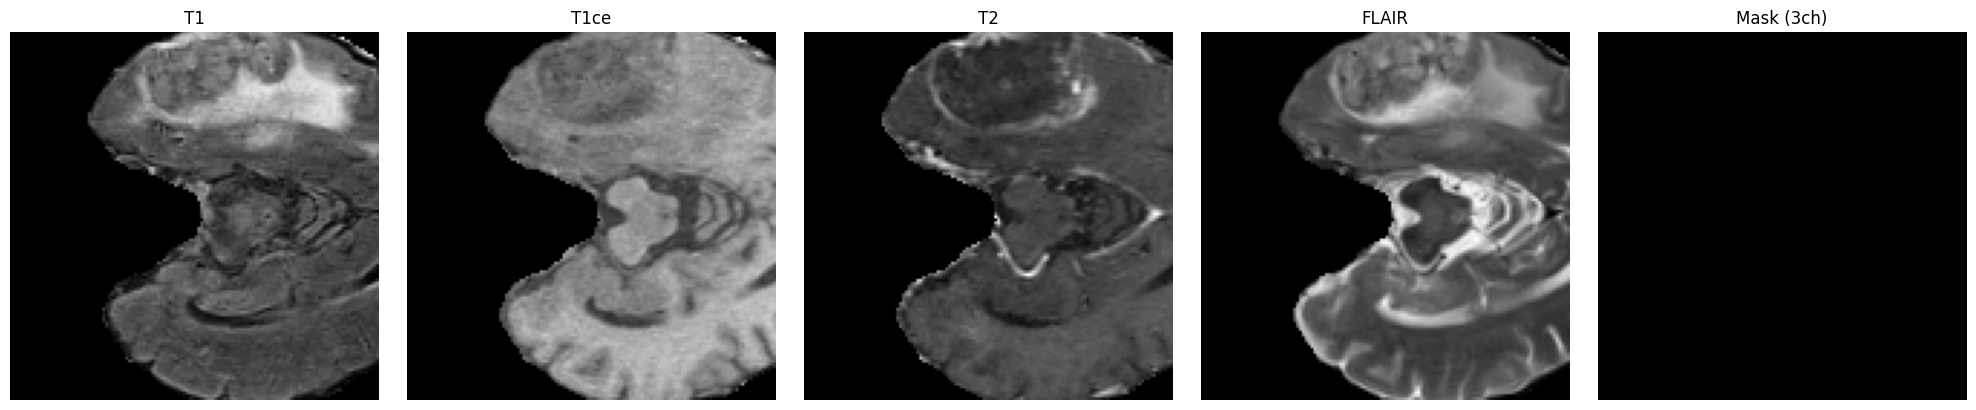

In [12]:
# Preview a sample with tumor
with h5py.File(os.path.join(DATA_DIR, tumor_files[25]), 'r') as f:
    img = f['image'][:]
    mask = f['mask'][:]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
titles = ['T1', 'T1ce', 'T2', 'FLAIR', 'Mask']
for i in range(4):
    axes[i].imshow(cropcentre(img[:,:,i], 128, 128), cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')
# Show mask as composite of 3 channels
axes[4].imshow(cropcentre(mask, 128, 128))
axes[4].set_title('Mask (3ch)')
axes[4].axis('off')
plt.tight_layout()

# Dataset

In [13]:
class BraTSDataset(Dataset):
    def __init__(self, file_list, data_dir, crop_size=128, augmentation=None):
        self.file_list = file_list
        self.data_dir = data_dir
        self.crop_size = crop_size
        self.augmentation = augmentation

    def __getitem__(self, idx):
        with h5py.File(os.path.join(self.data_dir, self.file_list[idx]), 'r') as f:
            image = f['image'][:]  # (240, 240, 4)
            mask = f['mask'][:]    # (240, 240, 3)

        # Center crop
        image = cropcentre(image, self.crop_size, self.crop_size)  # (128, 128, 4)
        mask = cropcentre(mask, self.crop_size, self.crop_size)    # (128, 128, 3)

        # Split image channels: t1, t1ce, t2, flair
        t1 = image[:, :, 0]
        t1ce = image[:, :, 1]
        t2 = image[:, :, 2]
        flair = image[:, :, 3]

        if self.augmentation:
            augmented = self.augmentation(image=flair, mask=mask,
                                         t1=t1, t1ce=t1ce, t2=t2)
            flair = augmented['image']
            mask = augmented['mask']
            t1 = augmented['t1']
            t1ce = augmented['t1ce']
            t2 = augmented['t2']

        # Stack modalities → (4, H, W)
        input_tensor = torch.from_numpy(
            np.stack([t1, t1ce, t2, flair], axis=0)
        ).float()

        # Add background channel: background = where all 3 mask channels are 0
        # mask shape: (H, W, 3) → build (4, H, W) with background as channel 0
        mask = mask.astype(np.float32)
        bg = 1.0 - np.clip(mask.sum(axis=2, keepdims=True), 0, 1)  # (H, W, 1)
        mask_4ch = np.concatenate([bg, mask], axis=2)  # (H, W, 4)
        mask_tensor = torch.from_numpy(mask_4ch).permute(2, 0, 1).long()  # (4, H, W)

        return input_tensor, mask_tensor

    def __len__(self):
        return len(self.file_list)

In [14]:
augmentation = A.Compose([
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
        A.GridDistortion(p=0.5),
        A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5)                  
        ], p=0.8),
    A.RandomBrightnessContrast(p=0.8),
    ], 
    additional_targets={'t1':'image',
                          't1ce':'image',
                          't2':'image'})

valid_test_dataset = BraTSDataset(file_list=tumor_files,
                                  data_dir=DATA_DIR,
                                  augmentation=None)

train_dataset = BraTSDataset(file_list=tumor_files,
                              data_dir=DATA_DIR,
                              augmentation=augmentation)

# take 60%/20%/20% of the dataset for train/val/test 
train_length=int(0.6 * len(valid_test_dataset))
valid_length = int(0.2 * len(valid_test_dataset))
test_length = len(valid_test_dataset) - train_length - valid_length

_, valid_dataset, test_dataset = torch.utils.data.random_split(valid_test_dataset, (train_length,valid_length,test_length), generator=torch.Generator().manual_seed(42))

train_dataset, _, _ = torch.utils.data.random_split(train_dataset, (train_length,valid_length,test_length), generator=torch.Generator().manual_seed(42))


train_loader= DataLoader(train_dataset,
                      batch_size=1,
                      num_workers=0,
                      shuffle=True)

valid_loader= DataLoader(valid_dataset,
                      batch_size=1,
                      num_workers=0,
                      shuffle=False)

test_loader= DataLoader(test_dataset,
                      batch_size=1,
                      num_workers=0,
                      shuffle=False)

C:\Users\bhmed\AppData\Local\Temp\ipykernel_11116\72934518.py:3: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03, p=0.5),
C:\Users\bhmed\AppData\Local\Temp\ipykernel_11116\72934518.py:5: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=2, shift_limit=0.5, p=0.5)


In [15]:
a,b=next(iter(train_loader))

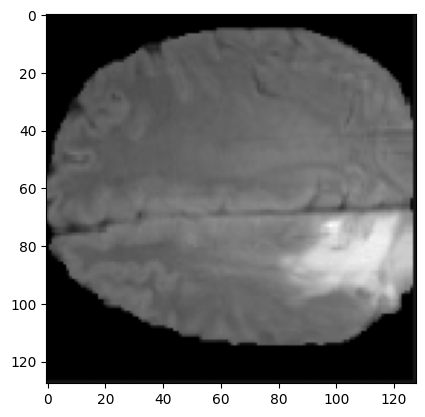

In [16]:
plt.imshow(a[0,0],cmap='gray')

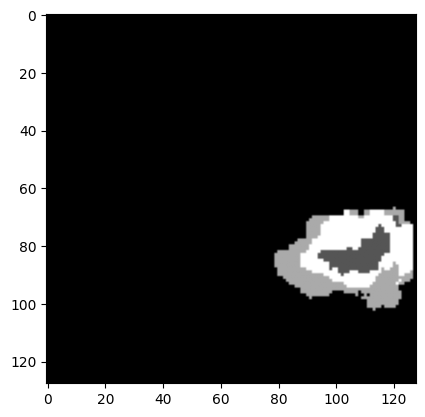

In [17]:
bb = torch.argmax(b,1)
plt.imshow(bb[0],cmap='gray')

# Train Model

In [18]:
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda:0
NVIDIA GeForce RTX 3060 Laptop GPU


In [19]:
# import model
MODEL = smp.Unet(encoder_name='resnet50',
                 encoder_depth=5,
                 encoder_weights='imagenet',
                 decoder_channels=[1024,512,256,128,64],
                 in_channels=4,
                 classes=4,
                 activation=None)

c:\Users\bhmed\anaconda3\envs\brats\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\bhmed\.cache\huggingface\hub\models--smp-hub--resnet50.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [21]:
backgroundchannel = [0]

DICE_LOSS = smp.losses.DiceLoss(mode='multiclass', from_logits=True)

OPTIMIZER = torch.optim.Adam([ 
    dict(params=MODEL.parameters(), lr=0.0001),
])

def compute_fscore(pred, target, ignore_channels=None, eps=1e-7):
    """Compute F-score (Dice) from logits and one-hot target."""
    pred_soft = torch.softmax(pred, dim=1)
    num_classes = pred_soft.shape[1]
    scores = []
    for c in range(num_classes):
        if ignore_channels and c in ignore_channels:
            continue
        p = pred_soft[:, c].reshape(-1)
        t = target[:, c].float().reshape(-1)
        tp = (p * t).sum()
        score = (2 * tp + eps) / (p.sum() + t.sum() + eps)
        scores.append(score)
    return torch.stack(scores).mean().item()

def compute_iou(pred, target, ignore_channels=None, threshold=0.5, eps=1e-7):
    """Compute IoU from logits and one-hot target."""
    pred_soft = torch.softmax(pred, dim=1)
    pred_bin = (pred_soft > threshold).float()
    num_classes = pred_soft.shape[1]
    scores = []
    for c in range(num_classes):
        if ignore_channels and c in ignore_channels:
            continue
        p = pred_bin[:, c].reshape(-1)
        t = target[:, c].float().reshape(-1)
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        score = (inter + eps) / (union + eps)
        scores.append(score)
    return torch.stack(scores).mean().item()

In [26]:
max_dice_score = 0
stats = {
    'train_loss' : [],
    'valid_loss' : [],
    'fscore' : [],
    'iou_score' : []
}

for epoch in range(1):
    print(f'\n --- Epoch {epoch} --- ')

    # --- Train ---
    MODEL.train()
    MODEL.to(DEVICE)
    train_loss_sum = 0
    for inp, gt in tqdm(train_loader, desc='Train', leave=False):
        inp, gt = inp.to(DEVICE), gt.to(DEVICE)
        OPTIMIZER.zero_grad()
        pred = MODEL(inp)
        gt_labels = torch.argmax(gt, dim=1)  # (B, H, W) class indices
        loss = DICE_LOSS(pred, gt_labels)
        loss.backward()
        OPTIMIZER.step()
        train_loss_sum += loss.item()
    train_loss_avg = train_loss_sum / len(train_loader)
    print(f'Train loss: {train_loss_avg:.4f}')

    # --- Validation ---
    MODEL.eval()
    val_loss_sum = 0
    val_fscore_sum = 0
    val_iou_sum = 0
    with torch.no_grad():
        for inp, gt in tqdm(valid_loader, desc='Valid', leave=False):
            inp, gt = inp.to(DEVICE), gt.to(DEVICE)
            pred = MODEL(inp)
            gt_labels = torch.argmax(gt, dim=1)
            loss = DICE_LOSS(pred, gt_labels)
            val_loss_sum += loss.item()
            val_fscore_sum += compute_fscore(pred, gt, ignore_channels=backgroundchannel)
            val_iou_sum += compute_iou(pred, gt, ignore_channels=backgroundchannel)

    val_loss_avg = val_loss_sum / len(valid_loader)
    val_fscore_avg = val_fscore_sum / len(valid_loader)
    val_iou_avg = val_iou_sum / len(valid_loader)
    print(f'Valid loss: {val_loss_avg:.4f}  fscore: {val_fscore_avg:.4f}  iou: {val_iou_avg:.4f}')

    if max_dice_score < val_fscore_avg:
        max_dice_score = val_fscore_avg
        torch.save(MODEL.state_dict(), './model.pth')
        print('model saved!')

    stats['train_loss'].append(train_loss_avg)
    stats['valid_loss'].append(val_loss_avg)
    stats['fscore'].append(val_fscore_avg)
    stats['iou_score'].append(val_iou_avg)
    np.save('./model.npy', stats)


 --- Epoch 0 --- 


Train loss: 0.3449


Valid loss: 0.4254  fscore: 0.2227  iou: 0.1607
model saved!


Text(0.5, 1.0, 'Train and Validation Loss')

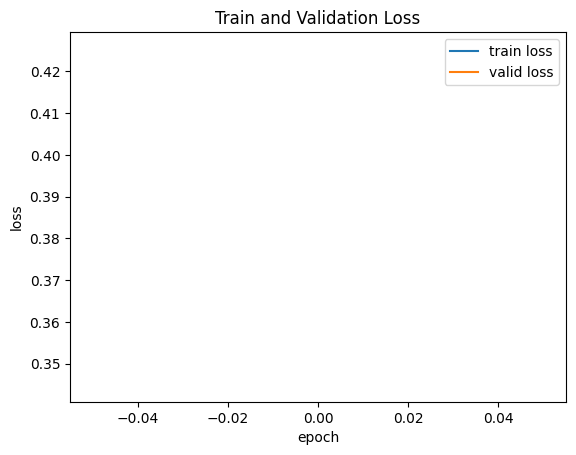

In [27]:
STATS = np.load(f'./model.npy', allow_pickle='TRUE').item()
plt.plot(STATS['train_loss'], label='train loss')
plt.plot(STATS['valid_loss'], label='valid loss')
plt.legend(loc='upper right')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Train and Validation Loss')

Text(0.5, 1.0, 'Fscore')

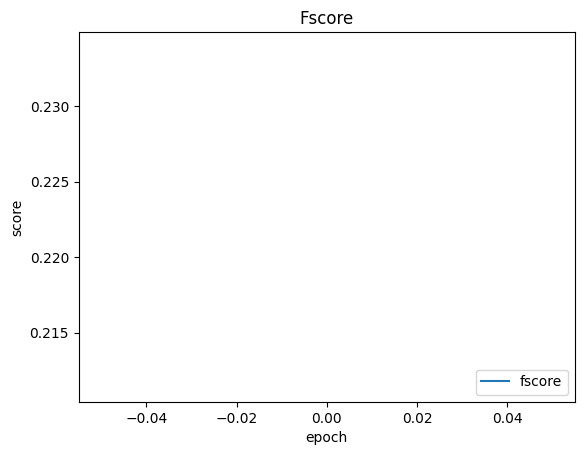

In [28]:
STATS = np.load(f'./model.npy', allow_pickle='TRUE').item()
plt.plot(STATS['fscore'], label='fscore')
plt.legend(loc="lower right")
plt.ylabel('score')
plt.xlabel('epoch')
plt.title('Fscore')

# Test Model

In [ ]:
MODEL.load_state_dict(torch.load('./model.pth'))

In [ ]:
subregions = {
    'all': [0],
    'ncr': [0,2,3],
    'ed': [0,1,3],
    'tc': [0,1,2],
}

MODEL.eval()
MODEL.to(DEVICE)
for subregion, ignore_ch in subregions.items():
    fscore_sum = 0
    with torch.no_grad():
        for inp, gt in test_loader:
            inp, gt = inp.to(DEVICE), gt.to(DEVICE)
            pred = MODEL(inp)
            fscore_sum += compute_fscore(pred, gt, ignore_channels=ignore_ch)
    print(f'{subregion}: {fscore_sum / len(test_loader):.4f}')

# Single Scan


In [ ]:
# Get slices from a single patient volume (e.g., volume_100)
single_patient_id = 'volume_100'
single_scan_files = sorted([f for f in tumor_files if f.startswith(single_patient_id + '_slice_')])
print(f'Volume "{single_patient_id}" tumor slices: {len(single_scan_files)}')

In [ ]:
# Preview slices from the single patient scan
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, fname in enumerate(single_scan_files[:5]):
    with h5py.File(os.path.join(DATA_DIR, fname), 'r') as f:
        img = cropcentre(f['image'][:], 128, 128)
        mask = cropcentre(f['mask'][:], 128, 128)
    axes[0, i].imshow(img[:,:,3], cmap='gray')  # FLAIR
    axes[0, i].set_title(fname.split('_slice_')[1].replace('.h5',''))
    axes[0, i].axis('off')
    axes[1, i].imshow(mask)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('FLAIR')
axes[1, 0].set_ylabel('Mask')
plt.suptitle(f'Single Patient Scan: {single_patient_id}')
plt.tight_layout()

In [ ]:
single_scan_dataset = BraTSDataset(file_list=single_scan_files,
                                    data_dir=DATA_DIR,
                                    augmentation=None)

single_scan_loader = DataLoader(single_scan_dataset,
                                 batch_size=1,
                                 num_workers=0,
                                 shuffle=False)

subregions = {
    'all': [0],
    'ncr': [0,2,3],
    'ed': [0,1,3],
    'tc': [0,1,2],
}

MODEL.eval()
MODEL.to(DEVICE)
print(f'--- Single Patient: {single_patient_id} ---')
for subregion, ignore_ch in subregions.items():
    fscore_sum = 0
    with torch.no_grad():
        for inp, gt in single_scan_loader:
            inp, gt = inp.to(DEVICE), gt.to(DEVICE)
            pred = MODEL(inp)
            fscore_sum += compute_fscore(pred, gt, ignore_channels=ignore_ch)
    print(f'{subregion}: {fscore_sum / len(single_scan_loader):.4f}')

# Per-Patient Evaluation


In [ ]:
# Get unique volume IDs from tumor files
volume_ids = sorted(set(f.split('_slice_')[0] for f in tumor_files))
print(f'Total patient volumes with tumor: {len(volume_ids)}')
print(f'First 10: {volume_ids[:10]}')

In [ ]:
# Evaluate per-patient Dice scores on a few patients
eval_volumes = volume_ids[:5]

MODEL.eval()
MODEL.to(DEVICE)
for vol_id in eval_volumes:
    vol_files = sorted([f for f in tumor_files if f.startswith(vol_id + '_slice_')])
    vol_dataset = BraTSDataset(file_list=vol_files, data_dir=DATA_DIR, augmentation=None)
    vol_loader = DataLoader(vol_dataset, batch_size=1, num_workers=0, shuffle=False)
    
    fscore_sum = 0
    with torch.no_grad():
        for inp, gt in vol_loader:
            inp, gt = inp.to(DEVICE), gt.to(DEVICE)
            pred = MODEL(inp)
            fscore_sum += compute_fscore(pred, gt, ignore_channels=[0])
    print(f'{vol_id}: fscore={fscore_sum / len(vol_loader):.4f} ({len(vol_files)} slices)')

In [ ]:
# Visualize predictions vs ground truth for a few test samples
MODEL.eval()
MODEL.to(DEVICE)

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
test_iter = iter(test_loader)
for i in range(5):
    inp, gt = next(test_iter)
    with torch.no_grad():
        pred = MODEL(inp.to(DEVICE))
    pred_mask = torch.argmax(pred, dim=1).cpu()
    gt_mask = torch.argmax(gt, dim=1).cpu()
    
    axes[0, i].imshow(inp[0, 3], cmap='gray')  # FLAIR
    axes[0, i].set_title(f'Sample {i}')
    axes[0, i].axis('off')
    axes[1, i].imshow(gt_mask[0], cmap='gray')
    axes[1, i].axis('off')
    axes[2, i].imshow(pred_mask[0], cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('FLAIR')
axes[1, 0].set_ylabel('Ground Truth')
axes[2, 0].set_ylabel('Prediction')
plt.tight_layout()

In [ ]:
# Per-subregion evaluation on the full test set
subregions = {
    'all': [0],
    'ncr': [0,2,3],
    'ed': [0,1,3],
    'tc': [0,1,2],
}

MODEL.eval()
MODEL.to(DEVICE)
print('--- Test Set Per-Subregion ---')
for subregion, ignore_ch in subregions.items():
    fscore_sum = 0
    with torch.no_grad():
        for inp, gt in test_loader:
            inp, gt = inp.to(DEVICE), gt.to(DEVICE)
            pred = MODEL(inp)
            fscore_sum += compute_fscore(pred, gt, ignore_channels=ignore_ch)
    print(f'{subregion}: {fscore_sum / len(test_loader):.4f}')

# Load model/statistics

In [ ]:
MODEL = smp.Unet(encoder_name='resnet50',
                 encoder_depth=5,
                 encoder_weights='imagenet',
                 decoder_channels=[1024,512,256,128,64],
                 in_channels=4,
                 classes=4,
                 activation=None)

MODEL.load_state_dict(torch.load('./model.pth', weights_only=True))
STATS = np.load('./model.npy', allow_pickle=True).item()